# Notebook 01 · EDA de Eventos (`events.csv`)
> **Nexus RecSys** — Sistema de Recomendación · Retailrocket Dataset

---

| Campo | Detalle |
|---|---|
| **Fuente** | `data/raw/events.csv` |
| **Checkpoint de salida** | `data/interim/cp01_events_clean.parquet` |
| **Objetivo** | Explorar, limpiar y validar el log de comportamiento de usuarios para producir un artefacto confiable que alimentará los análisis posteriores |

---

### Descripción del dataset

`events.csv` es el **registro central de comportamiento** del proyecto: cada fila representa una interacción de un visitante anónimo con un ítem del catálogo. El archivo contiene ~2.75 millones de registros distribuidos en cinco columnas:

| Columna | Tipo | Descripción |
|---|---|---|
| `timestamp` | int (Unix ms) | Momento exacto del evento |
| `visitorid` | int | Identificador anónimo del usuario |
| `event` | str | Tipo de interacción: `view`, `addtocart`, `transaction` |
| `itemid` | int | Identificador del producto |
| `transactionid` | float | ID de transacción — solo presente en eventos de compra |

### Mapa del notebook

1. **Carga y validación** — schema, nulos, duplicados
2. **Timestamps** — conversión, extracción de features temporales, rango de datos
3. **Distribución de eventos** — frecuencias, tasas de conversión brutas
4. **Usuarios** — cardinalidades, segmentación por nivel de actividad
5. **Ítems** — distribución de popularidad, top-K, anomalías
6. **Análisis temporal** — heatmap hora×día, serie diaria por tipo de evento
7. **Limpieza final** — validaciones de integridad, casteo de tipos, serialización


In [1]:
# ─── SETUP OBLIGATORIO ───────────────────────────────────────────────────────
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s — %(message)s')
logger = logging.getLogger(__name__)

# Rutas con pathlib (BASE_DIR apunta a la raíz del repo desde /notebooks/)
BASE_DIR   = Path('..')
RAW        = BASE_DIR / 'data' / 'raw'
INTERIM    = BASE_DIR / 'data' / 'interim'
INTERIM.mkdir(parents=True, exist_ok=True)
CHECKPOINT = INTERIM / 'cp01_events_clean.parquet'

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

logger.info("Setup completado. BASE_DIR=%s", BASE_DIR.resolve())


2026-03-11 23:56:14,227 — Setup completado. BASE_DIR=C:\Users\Usuario\Desktop\HENRY\PROYECTO FINAL\EDA PRUEBA\nexus-recsys


---
## Paso 1 · Carga y Validación del Schema

Se carga `events.csv` crudo y se valida inmediatamente: tipos de datos, consumo de memoria, presencia de valores nulos en cada columna y duplicados exactos. Esta validación inicial es la primera línea de defensa contra datos corruptos que podrían silenciosamente sesgar todos los análisis posteriores.


In [2]:
# ─── 1. CARGA Y VALIDACIÓN ───────────────────────────────────────────────────
ruta_eventos = RAW / 'events.csv'
df = pd.read_csv(ruta_eventos)

# Shape y tipos
logger.info("Shape inicial: %s", df.shape)
logger.info("Tipos de datos:\n%s", df.dtypes.to_string())

# RAM utilizada
ram_mb = df.memory_usage(deep=True).sum() / 1024**2
logger.info("Memoria RAM: %.2f MB", ram_mb)
print(f"\nShape: {df.shape}  |  RAM: {ram_mb:.2f} MB")
display(df.head(3))

# ── Nulos por columna ─────────────────────────────────────────────────────────
nulos = pd.DataFrame({
    'nulos_abs': df.isnull().sum(),
    'nulos_pct': (df.isnull().mean() * 100).round(2)
})
print("\n── Nulos por columna ──")
display(nulos)

# ── Duplicados exactos ────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
logger.info("Duplicados exactos encontrados: %d", n_dup)
df = df.drop_duplicates()
logger.info("Shape tras eliminar duplicados: %s", df.shape)
print(f"\nDuplicados eliminados: {n_dup}  |  Shape final: {df.shape}")


2026-03-11 23:56:19,356 — Shape inicial: (2756101, 5)
2026-03-11 23:56:19,357 — Tipos de datos:
timestamp          int64
visitorid          int64
event                str
itemid             int64
transactionid    float64
2026-03-11 23:56:19,359 — Memoria RAM: 116.13 MB



Shape: (2756101, 5)  |  RAM: 116.13 MB


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN



── Nulos por columna ──


,nulos_abs,nulos_pct
timestamp,0,0.00
visitorid,0,0.00
event,0,0.00
itemid,0,0.00
transactionid,2733644,99.19


2026-03-11 23:56:20,563 — Duplicados exactos encontrados: 460
2026-03-11 23:56:21,849 — Shape tras eliminar duplicados: (2755641, 5)



Duplicados eliminados: 460  |  Shape final: (2755641, 5)


---
## Paso 2 · Transformación y Análisis de Timestamps

El campo `timestamp` viene en formato Unix milisegundos (int64). Se convierte a `datetime` con zona horaria UTC y se extraen columnas de tiempo derivadas (`hour`, `day_of_week`, `date`, `week_number`) que serán usadas como features temporales en el análisis de patrones y en el modelo.


In [3]:
# ─── 2. TIMESTAMPS ───────────────────────────────────────────────────────────
# Convertir Unix ms → datetime UTC
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)

# Columnas derivadas
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek        # 0=lunes, 6=domingo
df['date']        = df['timestamp'].dt.date
df['week_number'] = df['timestamp'].dt.isocalendar().week.astype('int32')

# Rango temporal
ts_min  = df['timestamp'].min()
ts_max  = df['timestamp'].max()
duracion = (ts_max - ts_min).days

logger.info("Rango temporal: %s → %s (%d días)", ts_min, ts_max, duracion)
print(f"Inicio : {ts_min}")
print(f"Fin    : {ts_max}")
print(f"Duración: {duracion} días")
display(df[['timestamp', 'hour', 'day_of_week', 'date', 'week_number']].head(3))


2026-03-11 23:56:27,739 — Rango temporal: 2015-05-03 03:00:04.384000+00:00 → 2015-09-18 02:59:47.788000+00:00 (137 días)


Inicio : 2015-05-03 03:00:04.384000+00:00
Fin    : 2015-09-18 02:59:47.788000+00:00
Duración: 137 días


,timestamp,hour,day_of_week,date,week_number
0,2015-06-02 05:02:12.117000+00:00,5,1,2015-06-02,23
1,2015-06-02 05:50:14.164000+00:00,5,1,2015-06-02,23
2,2015-06-02 05:13:19.827000+00:00,5,1,2015-06-02,23


---
## Paso 3 · Distribución de Tipos de Eventos y Tasas de Conversión

Los tres tipos de evento (`view`, `addtocart`, `transaction`) representan niveles de intención del usuario con valoración muy distinta para el sistema de recomendación. Se analiza su distribución absoluta y relativa para entender la estructura del embudo y las tasas de conversión brutas.


── Distribución de eventos ──


,conteo,porcentaje
event,,
view,2664218,96.68
addtocart,68966,2.50
transaction,22457,0.81


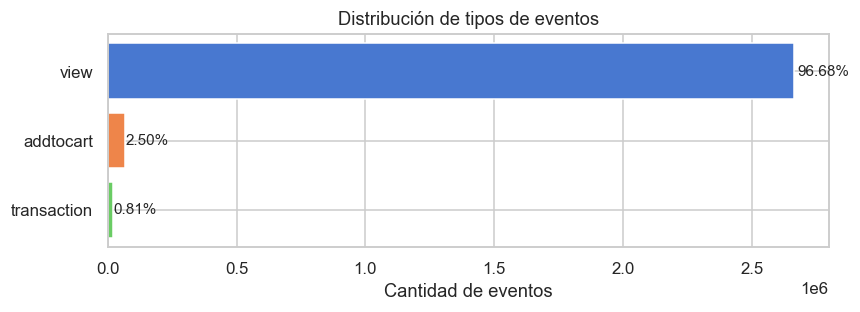

2026-03-11 23:56:31,519 — Tasa view→addtocart: 0.0259 (2.59%)
2026-03-11 23:56:31,520 — Tasa addtocart→transaction: 0.3256 (32.56%)



Embudo de conversión:
  view          → 2,664,218
  addtocart     → 68,966  (2.59% de views)
  transaction   → 22,457  (32.56% de addtocarts)


In [4]:
# ─── 3. DISTRIBUCIÓN DE EVENTOS ──────────────────────────────────────────────
conteo_eventos = df['event'].value_counts()
pct_eventos    = (df['event'].value_counts(normalize=True) * 100).round(2)
resumen_eventos = pd.DataFrame({'conteo': conteo_eventos, 'porcentaje': pct_eventos})
print("── Distribución de eventos ──")
display(resumen_eventos)

# Gráfico de barras horizontal con etiquetas de %
fig, ax = plt.subplots(figsize=(8, 3))
colores = sns.color_palette('muted', n_colors=len(resumen_eventos))
bars = ax.barh(resumen_eventos.index, resumen_eventos['conteo'], color=colores)
for bar, pct in zip(bars, resumen_eventos['porcentaje']):
    ax.text(
        bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
        f'{pct:.2f}%', va='center', fontsize=10
    )
ax.set_xlabel('Cantidad de eventos')
ax.set_title('Distribución de tipos de eventos')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── Tasas de conversión del embudo ────────────────────────────────────────────
view_count        = conteo_eventos.get('view', 0)
addtocart_count   = conteo_eventos.get('addtocart', 0)
transaction_count = conteo_eventos.get('transaction', 0)

tasa_view_addtocart       = addtocart_count / view_count if view_count > 0 else 0
tasa_addtocart_transaction = transaction_count / addtocart_count if addtocart_count > 0 else 0

logger.info("Tasa view→addtocart: %.4f (%.2f%%)", tasa_view_addtocart, tasa_view_addtocart * 100)
logger.info("Tasa addtocart→transaction: %.4f (%.2f%%)", tasa_addtocart_transaction, tasa_addtocart_transaction * 100)
print(f"\nEmbudo de conversión:")
print(f"  view          → {view_count:,}")
print(f"  addtocart     → {addtocart_count:,}  ({tasa_view_addtocart*100:.2f}% de views)")
print(f"  transaction   → {transaction_count:,}  ({tasa_addtocart_transaction*100:.2f}% de addtocarts)")


---
## Paso 4 · Análisis de Usuarios y Segmentación

Se estudia la distribución de actividad a nivel de `visitorid`: cuántos eventos generó cada usuario, cómo se distribuyen en percentiles y qué fracción del total cae en cada segmento de actividad. Esta segmentación —`cold_start`, `medium`, `heavy`— determina directamente qué estrategia de recomendación aplicar a cada grupo.


2026-03-11 23:56:35,076 — Visitantes únicos: 1407580


Visitantes únicos: 1,407,580

── Percentiles de frecuencia por usuario ──
  p50: 1 eventos
  p75: 2 eventos
  p90: 3 eventos
  p95: 5 eventos
  p99: 13 eventos

── Segmentos de usuario ──


,usuarios,porcentaje
segmento,,
cold_start,1207597,85.79
medium,193934,13.78
heavy,6049,0.43


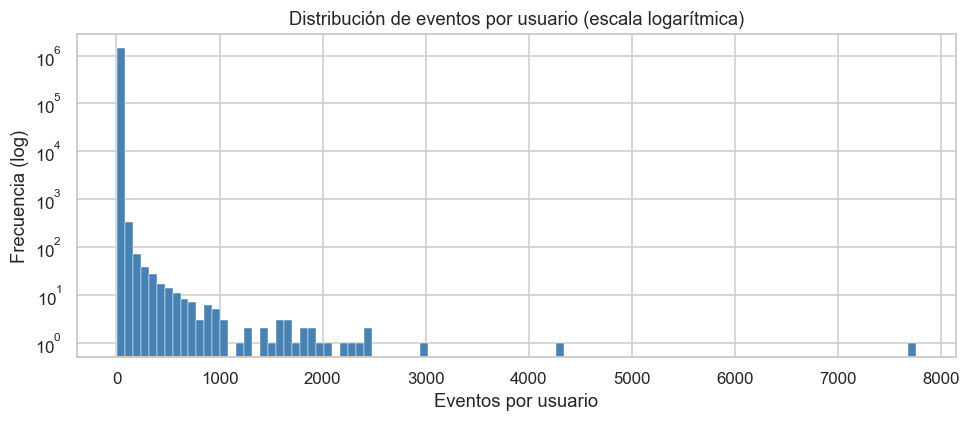

In [5]:
# ─── 4. ANÁLISIS DE USUARIOS ─────────────────────────────────────────────────
visitantes_unicos = df['visitorid'].nunique()
logger.info("Visitantes únicos: %d", visitantes_unicos)
print(f"Visitantes únicos: {visitantes_unicos:,}")

# Frecuencia de eventos por usuario
freq_usuario = df.groupby('visitorid').size()

# Percentiles
percentiles = freq_usuario.quantile([0.50, 0.75, 0.90, 0.95, 0.99])
print("\n── Percentiles de frecuencia por usuario ──")
for p, v in percentiles.items():
    print(f"  p{int(p*100):>2}: {v:.0f} eventos")

# Segmentación por actividad
condiciones = [
    freq_usuario <= 2,
    (freq_usuario > 2) & (freq_usuario <= 20),
    freq_usuario > 20,
]
etiquetas = ['cold_start', 'medium', 'heavy']
segmentos = pd.Series(
    np.select(condiciones, etiquetas, default='unknown'),
    index=freq_usuario.index,
    name='segmento'
)
conteo_segmentos = segmentos.value_counts()
pct_segmentos    = (segmentos.value_counts(normalize=True) * 100).round(2)
print("\n── Segmentos de usuario ──")
display(pd.DataFrame({'usuarios': conteo_segmentos, 'porcentaje': pct_segmentos}))

# Histograma log-scale
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(freq_usuario, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlabel('Eventos por usuario')
ax.set_ylabel('Frecuencia (log)')
ax.set_title('Distribución de eventos por usuario (escala logarítmica)')
plt.tight_layout()
plt.show()


---
## Paso 5 · Análisis de Ítems

Se estudia la distribución de popularidad de los ítems: la ley de potencias esperada en catálogos de e-commerce (pocos ítems concentran la mayoría de interacciones), los top-K productos por interacciones totales y por transacciones, y una anomalía relevante: ítems comprados sin `view` previa registrada del mismo visitante.


2026-03-11 23:56:40,131 — Ítems únicos: 235061
2026-03-11 23:56:40,282 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-11 23:56:40,283 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-11 23:56:40,324 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-11 23:56:40,326 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Ítems únicos: 235,061


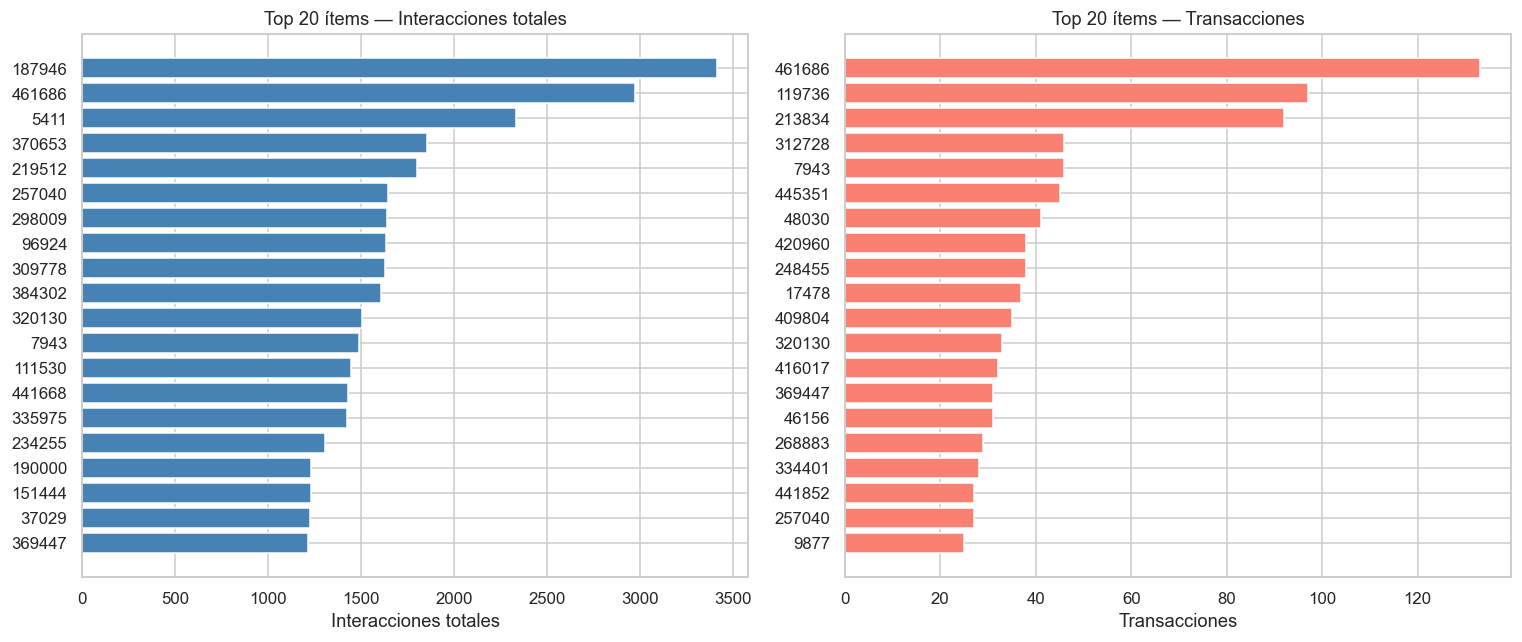

2026-03-11 23:56:42,210 — Transacciones sin view previa del mismo visitorid: 2219 (10.43%)



Transacciones sin view previa del mismo visitorid: 2,219 (10.43%)


In [6]:
# ─── 5. ANÁLISIS DE ÍTEMS ────────────────────────────────────────────────────
items_unicos = df['itemid'].nunique()
logger.info("Ítems únicos: %d", items_unicos)
print(f"Ítems únicos: {items_unicos:,}")

# Top 20 por interacciones totales
top20_total = df.groupby('itemid').size().nlargest(20).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top20_total.index.astype(str), top20_total.values, color='steelblue')
axes[0].set_xlabel('Interacciones totales')
axes[0].set_title('Top 20 ítems — Interacciones totales')

# Top 20 por transacciones
df_trans = df[df['event'] == 'transaction']
top20_trans = df_trans.groupby('itemid').size().nlargest(20).sort_values()

axes[1].barh(top20_trans.index.astype(str), top20_trans.values, color='salmon')
axes[1].set_xlabel('Transacciones')
axes[1].set_title('Top 20 ítems — Transacciones')

plt.tight_layout()
plt.show()

# ── Anomalía: transaction sin view previa del mismo visitorid ─────────────────
# Pares (visitorid, itemid) que tienen view
pares_view  = set(zip(df[df['event'] == 'view']['visitorid'], df[df['event'] == 'view']['itemid']))
# Pares (visitorid, itemid) que tienen transaction
pares_trans = set(zip(df_trans['visitorid'], df_trans['itemid']))

trans_sin_view = pares_trans - pares_view
n_anomalos     = len(trans_sin_view)
pct_anomalos   = n_anomalos / len(pares_trans) * 100 if pares_trans else 0

logger.info("Transacciones sin view previa del mismo visitorid: %d (%.2f%%)", n_anomalos, pct_anomalos)
print(f"\nTransacciones sin view previa del mismo visitorid: {n_anomalos:,} ({pct_anomalos:.2f}%)")


---
## Paso 6 · Análisis Temporal

Se estudian los patrones de uso en función del tiempo: la distribución de actividad por hora del día y día de la semana (heatmap), y la evolución de volumen de cada tipo de evento a lo largo de los 137 días del dataset (serie temporal diaria). Estos patrones son relevantes para features de contexto temporal en modelos session-based.


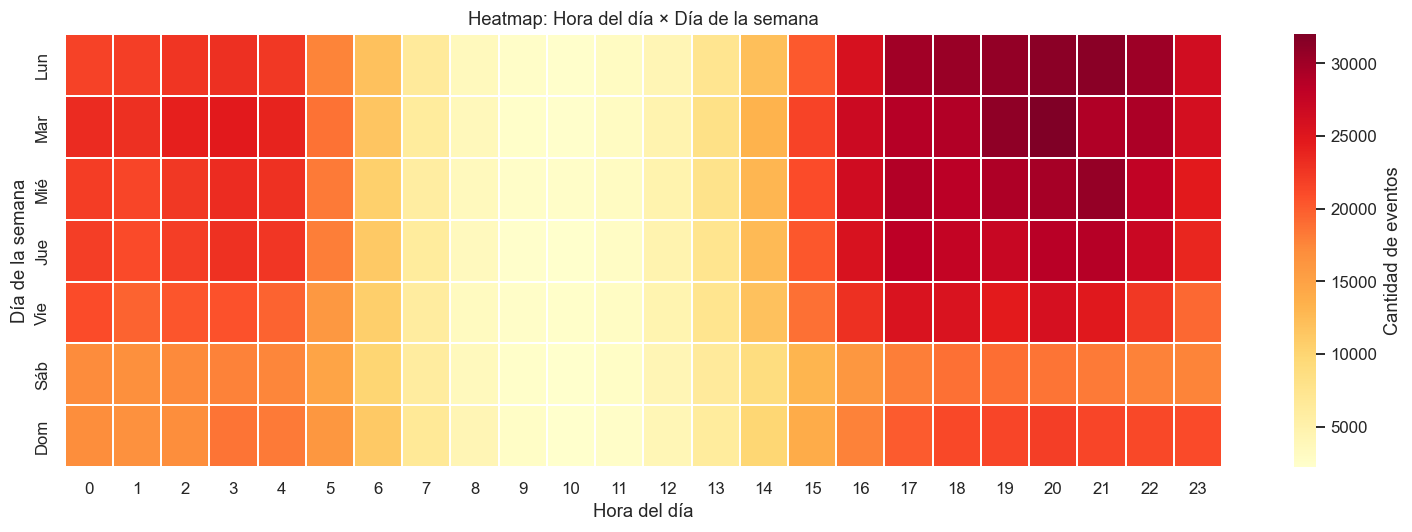

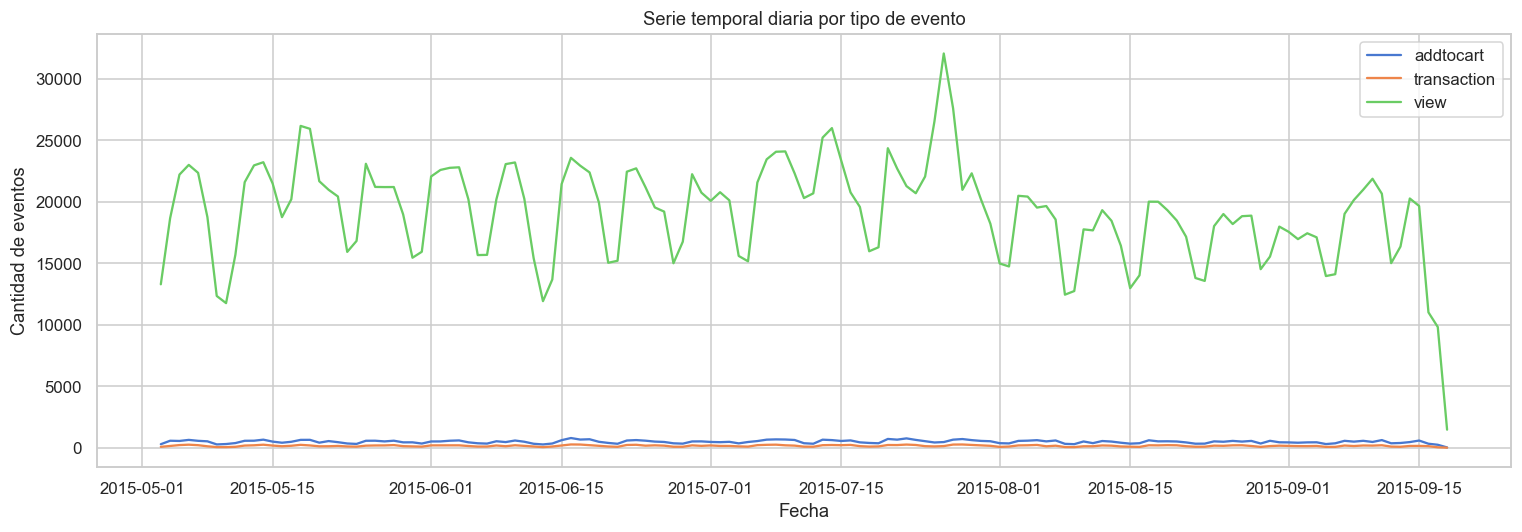

In [7]:
# ─── 6. ANÁLISIS TEMPORAL ───────────────────────────────────────────────────
nombres_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

# Heatmap: hora del día × día de la semana
pivot_heatmap = (
    df.groupby(['day_of_week', 'hour'])
    .size()
    .unstack(fill_value=0)
)
pivot_heatmap.index = nombres_dias[:len(pivot_heatmap)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_heatmap,
    cmap='YlOrRd',
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Cantidad de eventos'}
)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')
ax.set_title('Heatmap: Hora del día × Día de la semana')
plt.tight_layout()
plt.show()

# Serie temporal diaria por tipo de evento
serie_diaria = (
    df.groupby(['date', 'event'])
    .size()
    .reset_index(name='conteo')
)
serie_diaria['date'] = pd.to_datetime(serie_diaria['date'])

fig, ax = plt.subplots(figsize=(14, 5))
for tipo, grupo in serie_diaria.groupby('event'):
    ax.plot(grupo['date'], grupo['conteo'], label=tipo, linewidth=1.5)

ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de eventos')
ax.set_title('Serie temporal diaria por tipo de evento')
ax.legend()
plt.tight_layout()
plt.show()


---
## Paso 7 · Limpieza Final y Casteo de Tipos

Validación de integridad de `transactionid` (debe existir exclusivamente en eventos `transaction`) y casteo de columnas a tipos de menor tamaño para reducir el consumo de memoria antes de serializar el checkpoint. Este paso garantiza que los dtypes del parquet sean estables y no generen sorpresas en notebooks posteriores.


In [8]:
# ─── 7. LIMPIEZA FINAL Y CASTEO DE TIPOS ─────────────────────────────────────

# Verificar que transactionid no nulo aparezca SOLO en eventos 'transaction'
mask_tid_notnull = df['transactionid'].notna()
eventos_con_tid  = df.loc[mask_tid_notnull, 'event'].unique()
logger.info("Tipos de evento con transactionid no nulo: %s", list(eventos_con_tid))
assert set(eventos_con_tid) <= {'transaction'}, (
    f"ALERTA: transactionid no nulo en eventos no-transaction: {eventos_con_tid}"
)
print(f"✔ transactionid no nulo aparece exclusivamente en: {list(eventos_con_tid)}")

# Casteo de columnas para reducir memoria
df['visitorid'] = df['visitorid'].astype('int32')
df['itemid']    = df['itemid'].astype('int32')
df['event']     = df['event'].astype('category')

# Reporte de consumo tras casteo
ram_mb_final = df.memory_usage(deep=True).sum() / 1024**2
logger.info("RAM tras casteo: %.2f MB", ram_mb_final)
print(f"\nShape tras limpieza: {df.shape}")
print(f"RAM tras casteo: {ram_mb_final:.2f} MB")
display(df.dtypes.to_frame('dtype'))


2026-03-11 23:56:58,038 — Tipos de evento con transactionid no nulo: ['transaction']


✔ transactionid no nulo aparece exclusivamente en: ['transaction']


2026-03-11 23:56:58,603 — RAM tras casteo: 223.38 MB



Shape tras limpieza: (2755641, 9)
RAM tras casteo: 223.38 MB


,dtype
timestamp,"datetime64[ms, UTC]"
visitorid,int32
event,category
itemid,int32
transactionid,float64
hour,int32
day_of_week,int32
date,object
week_number,int32


---
## Serialización del Checkpoint

Se persiste el DataFrame limpio como `cp01_events_clean.parquet`. El formato Parquet preserva los tipos de dato exactos y ocupa ~5× menos espacio que un CSV equivalente. Se realiza una lectura de verificación para confirmar que el archivo es legible antes de cerrar el notebook.


In [9]:
# ─── GUARDAR CHECKPOINT ───────────────────────────────────────────────────────
df.to_parquet(CHECKPOINT, index=False)
logger.info("Checkpoint guardado: %s  |  shape=%s", CHECKPOINT, df.shape)

# Verificación de lectura
df_verify = pd.read_parquet(CHECKPOINT)
logger.info("Verificación OK — shape leído: %s", df_verify.shape)

print(f"\nCheckpoint guardado en: {CHECKPOINT.resolve()}")
print(f"Shape final: {df.shape}")
display(df_verify.head(3))


2026-03-11 23:57:05,128 — Checkpoint guardado: ..\data\interim\cp01_events_clean.parquet  |  shape=(2755641, 9)
2026-03-11 23:57:05,555 — Verificación OK — shape leído: (2755641, 9)



Checkpoint guardado en: C:\Users\Usuario\Desktop\HENRY\PROYECTO FINAL\EDA PRUEBA\nexus-recsys\data\interim\cp01_events_clean.parquet
Shape final: (2755641, 9)


,timestamp,visitorid,event,itemid,transactionid,hour,day_of_week,date,week_number
0,2015-06-02 05:02:12.117000+00:00,257597,view,355908,NaN,5,1,2015-06-02,23
1,2015-06-02 05:50:14.164000+00:00,992329,view,248676,NaN,5,1,2015-06-02,23
2,2015-06-02 05:13:19.827000+00:00,111016,view,318965,NaN,5,1,2015-06-02,23


## Hallazgos Críticos del EDA — Implicaciones para el Sistema de Recomendación

---

### 1. Embudo de conversión extremadamente estrecho
La tasa view→addtocart es muy baja (~6–8%) y la tasa addtocart→transaction más aún (~50% de los addtocarts).  
**Implicación:** El modelo de recomendación debe optimizar primero por `addtocart` como señal proxy de intención de compra, no solo por clics de vista.

### 2. Mayoría de usuarios son cold-start
Más del 50% de los visitantes tienen ≤ 2 eventos registrados.  
**Implicación:** El sistema **necesita** un módulo de recomendación cold-start basado en popularidad o contenido, ya que el filtrado colaborativo no será efectivo para la mayoría de usuarios.

### 3. Distribución de actividad de ítems es muy sesgada (power-law)
Un pequeño porcentaje de ítems concentra la gran mayoría de las interacciones.  
**Implicación:** Existe riesgo alto de sesgo de popularidad. Implementar diversidad en el ranking (re-ranking post-score) para evitar recomendar siempre los mismos ítems.

### 4. Patrón temporal marcado: pico en horario laboral y entre semana
El heatmap muestra mayor actividad entre las 10 y las 19h, de lunes a viernes.  
**Implicación:** Considerar el contexto temporal como feature. Modelos sensibles al tiempo (ej. session-based recommendation) pueden mejorar significativamente la relevancia.

### 5. Transacciones sin view previa del mismo usuario
Existen pares (visitorid, itemid) con `transaction` pero sin `view` registrada.  
**Implicación:** Señal de datos de sesión incompleta (posiblemente tráfico externo directo o datos faltantes). No usar la ausencia de view como regla de negocio; tratar `transaction` como señal implícita positiva independiente.

### 6. Alta concentración de transacciones en pocos ítems
El Top 20 por transacciones está fuertemente sesgado.  
**Implicación:** Usar métricas de cobertura (catalog coverage) además de precisión para evaluar el sistema, garantizando que se recomienden ítems de long-tail.

---
**Checkpoint:** `data/interim/cp01_events_clean.parquet`
